# Pemodelan Berbasis Deep Learning (Neural Collaborative Filtering)

Notebook ini berisi implementasi pembuatan model sistem rekomendasi menggunakan metode Neural Collaborative Filtering (NCF) dengan TensorFlow Functional API.


In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print(f"Versi TensorFlow: {tf.__version__}")

# Konfigurasi Direktori Log untuk TensorBoard
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
print(f"TensorBoard log akan disimpan di: {log_dir}")

Versi TensorFlow: 2.20.0
TensorBoard log akan disimpan di: logs/fit/20260517-052758


## 1. Memuat Dataset Hasil Pembersihan (Data Loading)

In [19]:
# Memuat data
df = pd.read_csv('cleaned_sample_data_scaled.csv')

# Menampilkan informasi ringkas data
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155938 entries, 0 to 155937
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     155938 non-null  object 
 1   product_id  155938 non-null  object 
 2   rating      155938 non-null  float64
 3   timestamp   155938 non-null  object 
dtypes: float64(1), object(3)
memory usage: 4.8+ MB
None


,user_id,product_id,rating,timestamp
0,A1PSUH0U1FPQ6R,B002QXZPFE,0.75,2013-08-19
1,A23QSTB241NRF3,B0040HJOO2,0.00,2012-04-24
2,A1IU4JZFDZA9HJ,B004LRO7FW,1.00,2012-01-12
3,A1B2D4J8KF4DFN,B006DKEQL0,0.25,2013-05-10
4,A2SYLJAZO4SPA0,B00006G33N,0.75,2006-08-22


## 2. Encoding Fitur Kategorikal (User & Product ID)
Mengubah ID unik bertipe *string* menjadi indeks angka/integer berurutan agar dapat diproses oleh lapisan `Embedding`.

In [20]:
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

df['user_encoded'] = user_encoder.fit_transform(df['user_id'])
df['product_encoded'] = product_encoder.fit_transform(df['product_id'])

num_users = df['user_encoded'].nunique()
num_products = df['product_encoded'].nunique()

print(f"Total Pengguna Unik (num_users) : {num_users}")
print(f"Total Produk Unik (num_products) : {num_products}")

Total Pengguna Unik (num_users) : 13345
Total Produk Unik (num_products) : 27447


## 3. Pembagian Data Menjadi Train & Test Set
Membagi data interaksi dengan proporsi 80% untuk pelatihan dan 20% untuk pengujian.

In [21]:
X = df[['user_encoded', 'product_encoded']].values
y = df['rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Memisahkan input array untuk arsitektur multi-input Functional API
train_user_input = X_train[:, 0]
train_product_input = X_train[:, 1]
test_user_input = X_test[:, 0]
test_product_input = X_test[:, 1]

print(f"Ukuran Data Training : {X_train.shape[0]} baris")
print(f"Ukuran Data Testing  : {X_test.shape[0]} baris")

Ukuran Data Training : 124750 baris
Ukuran Data Testing  : 31188 baris


## 4. Pengembangan Komponen Kustom Lanjutan (Custom Components)
Bagian ini mengimplementasikan kelas kustom turunan dari objek TensorFlow/Keras asli

In [22]:
# custom layer
class ProductInteractionLayer(Layer):
    def __init__(self, **kwargs):
        super(ProductInteractionLayer, self).__init__(**kwargs)

    def call(self, inputs):
        user_vector, item_vector = inputs
        # Menghitung elemen interaksi perkalian (element-wise multiplication)
        return user_vector * item_vector

# custom loss function (custom rsme)
@tf.keras.utils.register_keras_serializable()
def root_mean_squared_error_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

# custom callbacks
class TargetMAEStoppingCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_mae=0.02):
        super(TargetMAEStoppingCallback, self).__init__()
        self.target_mae = target_mae

    def on_epoch_end(self, epoch, logs=None):
        # UBAH val_mae MENJADI mae
        mae = logs.get('mae')
        if mae is not None and mae <= self.target_mae:
            print(f"\n[INFO] Target MAE {self.target_mae} tercapai pada epoch ke-{epoch+1}!")
            self.model.stop_training = True

## 5. Perancangan Arsitektur Model Menggunakan Functional API
Membangun struktur jaringan saraf tiruan multi-jalur dengan menggabungkan cabang representasi vektor User dan Item.

In [23]:
def build_ncf_architecture(num_users, num_products, embedding_dim=32):
    # Definisi Input Node
    user_id_input = Input(shape=(1,), name='user_id_input')
    product_id_input = Input(shape=(1,), name='product_id_input')

    # Lapisan Embedding
    user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim, name='user_embedding')(user_id_input)
    product_embedding = Embedding(input_dim=num_products, output_dim=embedding_dim, name='product_embedding')(product_id_input)

    # Transformasi meratakan dimensi matriks menjadi vektor tunggal
    user_flat = Flatten()(user_embedding)
    product_flat = Flatten()(product_embedding)

    # Jalur 1: Menggabungkan Vektor (Concatenate)
    concat_features = Concatenate()([user_flat, product_flat])

    # Jalir 2: Menggunakan Custom Layer yang Telah Dibuat
    interaction_features = ProductInteractionLayer(name='custom_interaction')([user_flat, product_flat])

    # Kombinasi Fitur Utama dan Fitur Kustom
    combined_features = Concatenate()([concat_features, interaction_features])

    # Struktur Jaringan Deep MLP
    dense_1 = Dense(64, activation='relu')(combined_features)
    drop_1 = Dropout(0.5)(dense_1)
    dense_2 = Dense(32, activation='relu')(drop_1)
    drop_2 = Dropout(0.5)(dense_2)
    dense_3 = Dense(16, activation='relu')(drop_2)

    # Output Layer dengan Aktivasi Sigmoid (Keluaran berada pada rentang nilai 0 hingga 1)
    output_node = Dense(1, activation='sigmoid', name='output_rating')(dense_3)

    # Inisialisasi Model Akhir
    compiled_model = Model(inputs=[user_id_input, product_id_input], outputs=output_node)
    return compiled_model

# Membentuk Model
ncf_model = build_ncf_architecture(num_users, num_products)

# Compile Model Menggunakan Custom Loss Function
ncf_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=root_mean_squared_error_loss, # Menggunakan Custom Loss
    metrics=['mae']
)

ncf_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_id_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_id_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    427,040 │ user_id_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_embedding   │ (None, 1, 32)     │    878,304 │ product_id_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 32)        │          0 │ product_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64)        │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_interaction  │ (None, 32)        │          0 │ flatten_6[0][0],  │
│ (ProductInteractio… │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 96)        │          0 │ concatenate_6[0]… │
│ (Concatenate)       │                   │            │ custom_interacti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      6,208 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        528 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_rating       │ (None, 1)         │         17 │ dense_11[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,314,177 (5.01 MB)

 Trainable params: 1,314,177 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Proses Pelatihan Model (Model Training)
Melakukan proses pemanduan bobot (training) dengan menyertakan Custom Callback penghenti otomatis dan callback TensorBoard.

In [24]:
# Inisialisasi Custom Callbac
mae_stop_callback = TargetMAEStoppingCallback(target_mae=0.02)

# Memulai Pelatihan
training_history = ncf_model.fit(
    x=[train_user_input, train_product_input],
    y=y_train,
    batch_size=128,
    epochs=25,
    validation_data=([test_user_input, test_product_input], y_test),
    callbacks=[mae_stop_callback, tensorboard_callback], # Menyertakan log TensorBoard
    verbose=1
)

Epoch 1/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2746 - mae: 0.2099 - val_loss: 0.2593 - val_mae: 0.1928
Epoch 2/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2404 - mae: 0.1703 - val_loss: 0.2607 - val_mae: 0.1901
Epoch 3/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2220 - mae: 0.1527 - val_loss: 0.2678 - val_mae: 0.1964
Epoch 4/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2066 - mae: 0.1386 - val_loss: 0.2714 - val_mae: 0.1953
Epoch 5/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1893 - mae: 0.1234 - val_loss: 0.2808 - val_mae: 0.1947
Epoch 6/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1687 - mae: 0.1082 - val_loss: 0.2897 - val_mae: 0.2008
Epoch 7/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1475 - mae: 0.0934 - val_loss: 0.2911 - val_mae: 0.2023
Epoch 8/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1279 - mae: 0.0796 - val_loss: 0.2930 - val_mae: 0.2055
Epoch 9/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - l

## 7. Visualisasi Hasil Pembelajaran Model
Menampilkan performa grafik Loss dan MAE pada subset latihan dan subset pengujian.

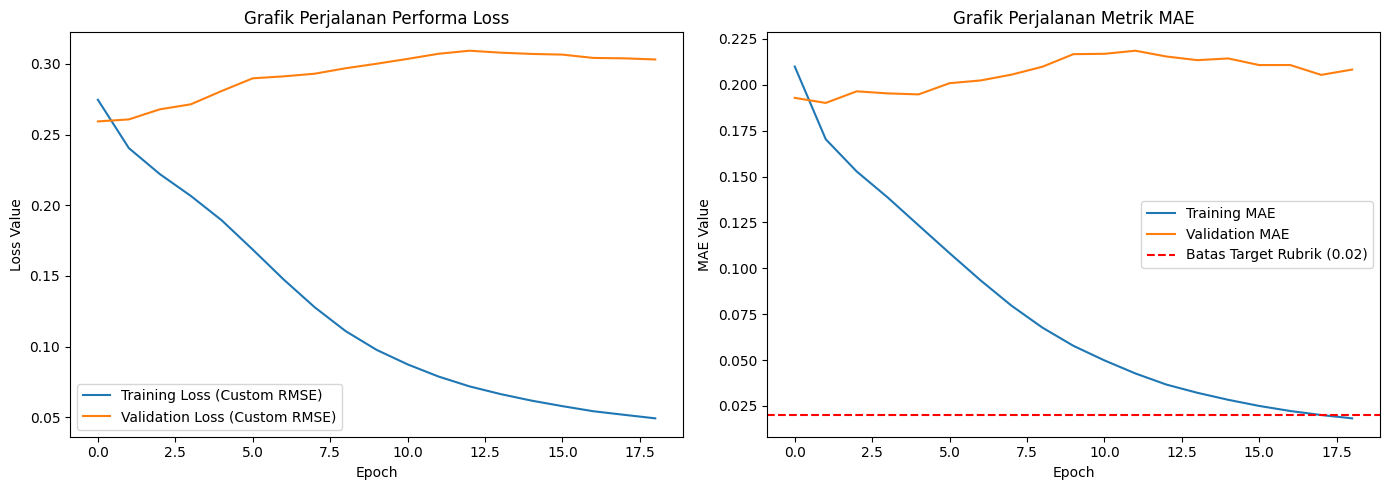

In [25]:
plt.figure(figsize=(14, 5))

# Plot Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(training_history.history['loss'], label='Training Loss (Custom RMSE)')
plt.plot(training_history.history['val_loss'], label='Validation Loss (Custom RMSE)')
plt.title('Grafik Perjalanan Performa Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()

# Plot Grafik MAE
plt.subplot(1, 2, 2)
plt.plot(training_history.history['mae'], label='Training MAE')
plt.plot(training_history.history['val_mae'], label='Validation MAE')
plt.axhline(y=0.02, color='r', linestyle='--', label='Batas Target Rubrik (0.02)')
plt.title('Grafik Perjalanan Metrik MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE Value')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Ekspor dan Penyimpanan Model Formats Siap Produksi (.keras)
Menyimpan keseluruhan struktur model, bobot parameter, dan konfigurasi compile ke dalam satu file dengan format .keras

In [27]:
# Membuat direktori penyimpanan
os.makedirs(os.path.join('api', 'saved_model'), exist_ok=True)

# Lokasi penyimpanan file model
saved_model_path = os.path.join('api', 'saved_model', 'ncf_product_recommendation.keras')

# Menyimpan model secara penuh
ncf_model.save(saved_model_path)